# Множественная линейная регрессия
## Данные о стоимости жилья в Калифорнии

Адаптация примера из курса «Построение моделей машинного обучения» к датасету
[California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices).

**Целевая переменная:** `median_house_value` — медианная стоимость дома в квартале (в USD).

**Признаки:**
| Признак | Описание |
|---|---|
| `longitude` | Долгота (чем больше — тем западнее) |
| `latitude` | Широта (чем больше — тем севернее) |
| `housing_median_age` | Медианный возраст домов в квартале |
| `total_rooms` | Общее число комнат в квартале |
| `total_bedrooms` | Общее число спален в квартале |
| `population` | Число жителей в квартале |
| `households` | Число домохозяйств в квартале |
| `median_income` | Медианный доход (в десятках тысяч USD) |
| `ocean_proximity` | Категория близости к океану |

## Импорт библиотек

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Загрузка данных

Данные сохранены в файл `california_housing.csv` рядом с ноутбуком.

In [190]:
file_id = '1BH38GayXJ_kgsMLZLio-grpua_5NFB3r'
file_url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Загружаем файл напрямую с URL в датафрейм
california = pd.read_csv(file_url)

california.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


### Структура датасета

In [191]:
california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


### Категориальный признак `ocean_proximity`

В датасете есть один категориальный признак — `ocean_proximity`.
Посмотрим на его распределение.

In [192]:
california.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


### Распределение числовых признаков

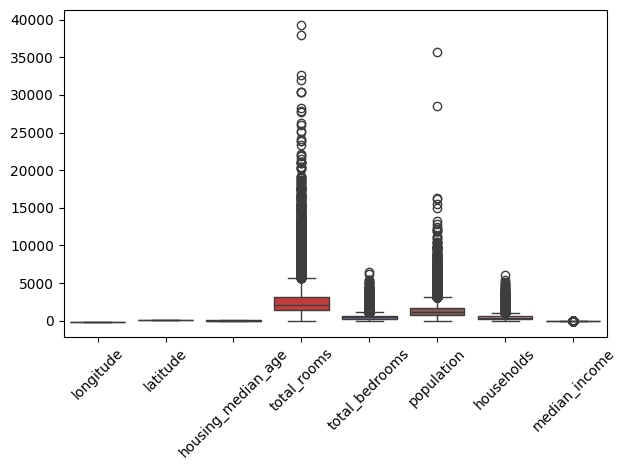

In [193]:
sns.boxplot(data=california.drop(columns=['ocean_proximity', 'median_house_value']))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Распределение целевой переменной

Text(0.5, 1.0, 'Медианный доход и цены на жилье')

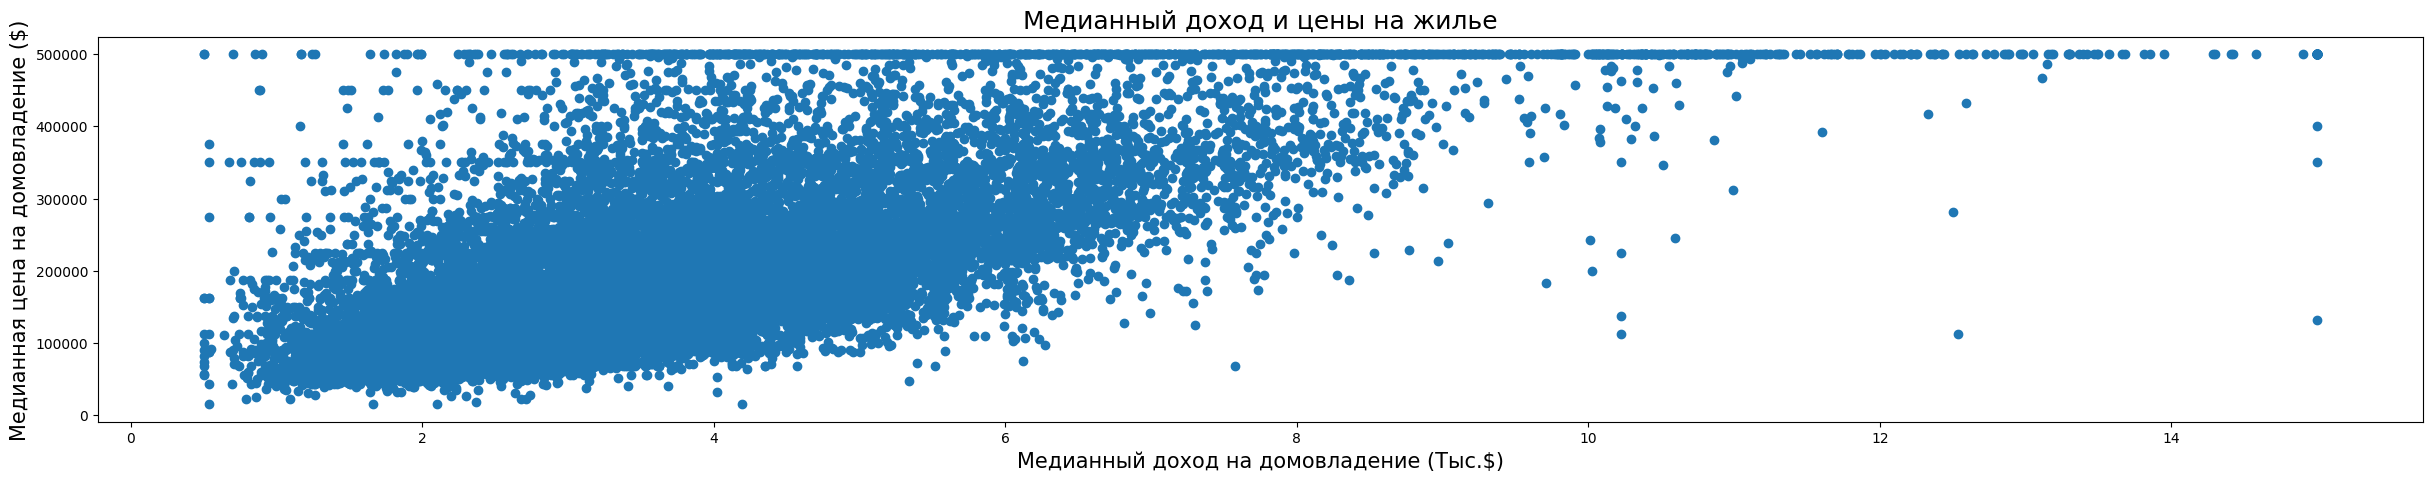

In [194]:
x = california['median_income']
y = california['median_house_value']

# зададим размер и построим первый график
plt.figure(figsize = (30,5))
plt.scatter(x,y)

# добавим подписи
plt.xlabel('Медианный доход на домовладение (Тыс.$)', fontsize = 15)
plt.ylabel('Медианная цена на домовладение ($)', fontsize = 15)
plt.title('Медианный доход и цены на жилье', fontsize = 18)

На графике видна аномальная сплошная линия для жилья, стоимость которого составляет $500 000. Это может быть связано с тем, что максимальная стоимость жилья ограничена этой цифрой.

Удалим все записи о жилье с этой стоимостью, чтобы избежать проблем с тренировкой моделей.

In [195]:
print(f"Original DataFrame shape: {california.shape}")
california = california[california['median_house_value'] < 500000]
print(f"Filtered DataFrame shape: {california.shape}")
california.head()

Original DataFrame shape: (20640, 10)
Filtered DataFrame shape: (19648, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


Text(0.5, 1.0, 'Медианный доход и цены на жилье')

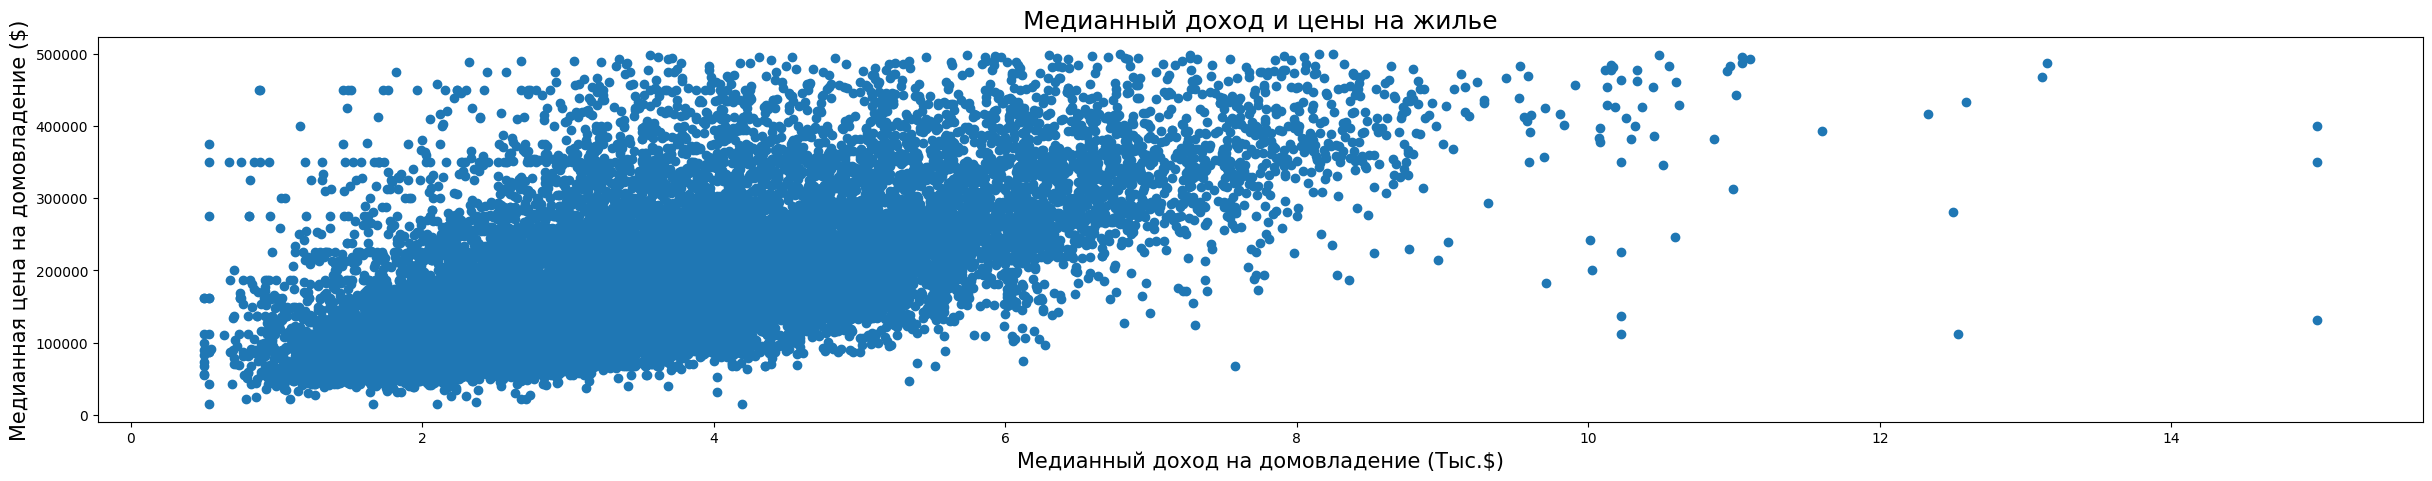

In [196]:
x = california['median_income']
y = california['median_house_value']

# зададим размер и построим первый график
plt.figure(figsize = (30,5))
plt.scatter(x,y)

# добавим подписи
plt.xlabel('Медианный доход на домовладение (Тыс.$)', fontsize = 15)
plt.ylabel('Медианная цена на домовладение ($)', fontsize = 15)
plt.title('Медианный доход и цены на жилье', fontsize = 18)

На новом графике видно, что аномалия пропала. Далее будем использовать отфильтрованные данные.

Используем вспомогательную функцию, которая строит boxplot и KDE-plot вместе.

In [197]:
def box_density(x):
    f, (ax_box, ax_kde) = plt.subplots(nrows=2,
                                        ncols=1,
                                        sharex=True,
                                        gridspec_kw={'height_ratios': (.15, .85)})
    sns.boxplot(x=x, ax=ax_box)
    ax_box.set(xlabel=None)
    sns.kdeplot(x, fill=True)

    ax_box.set_title('Распределение переменной', fontsize=15)
    ax_kde.set_xlabel('Переменная', fontsize=13)
    ax_kde.set_ylabel('Плотность распределения', fontsize=13)
    plt.show()

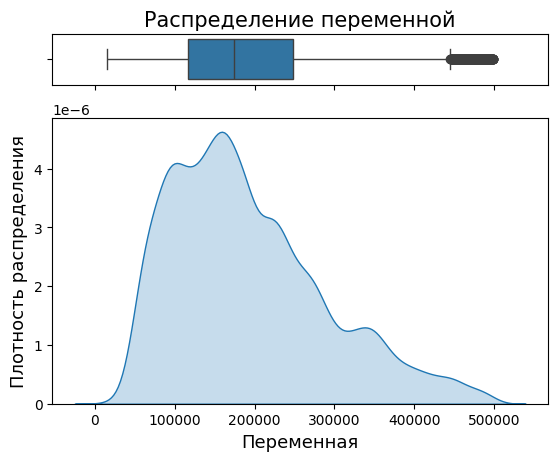

In [198]:
box_density(california.median_house_value)

### Корреляция числовых признаков с целевой переменной

In [199]:
california.drop(columns='ocean_proximity').corr()['median_house_value'].to_frame().style.background_gradient()

,median_house_value
longitude,-0.045733
latitude,-0.149257
housing_median_age,0.065139
total_rooms,0.144988
total_bedrooms,0.075219
population,0.013592
households,0.095634
median_income,0.646719
median_house_value,1.000000


**Наблюдение:** `median_income` имеет наиболее высокую положительную корреляцию
с ценой.

### Связь категориального признака `ocean_proximity` с целевой переменной

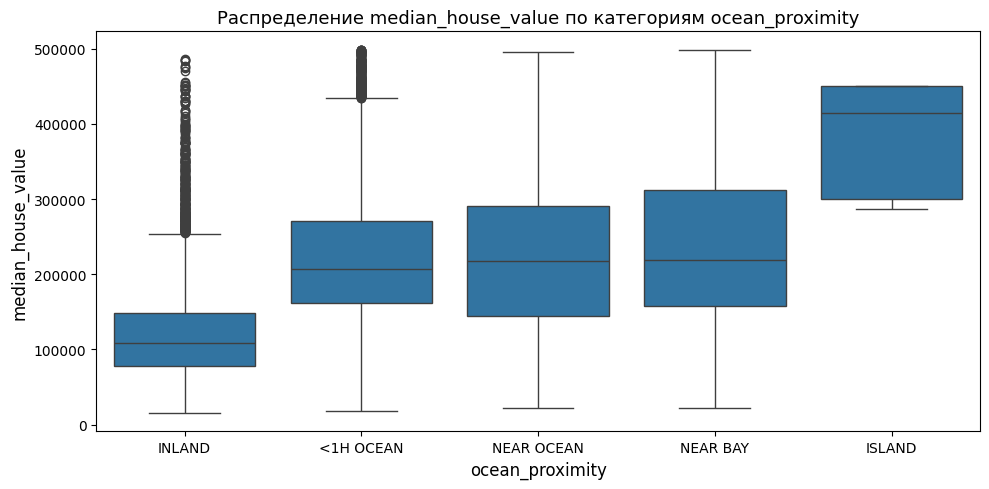

In [200]:
fig, ax = plt.subplots(figsize=(10, 5))
order = california.groupby('ocean_proximity')['median_house_value'].median().sort_values().index
sns.boxplot(data=california, x='ocean_proximity', y='median_house_value', order=order, ax=ax)
ax.set_title('Распределение median_house_value по категориям ocean_proximity', fontsize=13)
ax.set_xlabel('ocean_proximity', fontsize=12)
ax.set_ylabel('median_house_value', fontsize=12)
plt.tight_layout()
plt.show()

In [201]:
california.groupby('ocean_proximity')['median_house_value']\
    .agg(['mean', 'median', 'count'])\
    .sort_values('mean')\
    .style.background_gradient(subset=['mean', 'median'])

,mean,median,count
ocean_proximity,,,
INLAND,123194.863713,108300.000000,6523
<1H OCEAN,223724.200116,207400.000000,8595
NEAR OCEAN,226711.243332,217300.000000,2437
NEAR BAY,235917.624521,219150.000000,2088
ISLAND,380440.000000,414700.000000,5


Категория `ISLAND` имеет лишь 5 наблюдений - это слишком мало для обучения модели. Удалим их, чтобы они не влияли на правильность работы модели.

In [202]:
california = california[california.ocean_proximity != 'ISLAND']

california.groupby('ocean_proximity')['median_house_value']\
    .agg(['mean', 'median', 'count'])\
    .sort_values('mean')\
    .style.background_gradient(subset=['mean', 'median'])

,mean,median,count
ocean_proximity,,,
INLAND,123194.863713,108300.000000,6523
<1H OCEAN,223724.200116,207400.000000,8595
NEAR OCEAN,226711.243332,217300.000000,2437
NEAR BAY,235917.624521,219150.000000,2088


**Вывод:** Дома вблизи океана (`<1H OCEAN`, `NEAR OCEAN`, `NEAR BAY`) в среднем значительно
дороже, чем в глубине материка (`INLAND`).

### Пропущенные значения

In [203]:
california.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,200
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


В признаке `total_bedrooms` есть **200 пропущенных значений** (~1%).
Заполним их медианным значением — это стандартный подход для числовых признаков
с небольшой долей пропусков.

In [204]:
california['total_bedrooms'] = california['total_bedrooms'].fillna(
    california['total_bedrooms'].median()
)
california.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## Кодирование категориального признака

Модель линейной регрессии не работает с текстовыми категориями напрямую.
Используем **One-Hot Encoding** (OHE): каждая категория превращается в бинарный признак.

С параметром `drop_first=True` опускаем первую категорию по алфавиту (`<1H OCEAN`) —
она будет «базовой» категорией (intercept будет соответствовать ей).

In [205]:
california = pd.get_dummies(california, columns=['ocean_proximity'],
                           drop_first=True, dtype=float)

# Переименуем столбцы: уберём пробелы
california.columns = california.columns.str.replace(' ', '_')

# Перенесём целевую переменную в конец (удобно для дальнейших операций)
cols = [c for c in california.columns if c != 'median_house_value'] + ['median_house_value']
california = california[cols]

print(california.columns.tolist())
california.shape

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR_BAY', 'ocean_proximity_NEAR_OCEAN', 'median_house_value']


(19643, 12)

## Удаление выбросов

Используем **Isolation Forest** — алгоритм, который изолирует аномальные наблюдения.
Он хорошо работает для многомерных данных.

In [206]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples=100, random_state=42)
clf.fit(california)

california['anomaly'] = clf.predict(california)
california = california[california.anomaly == 1]
california = california.drop(columns='anomaly')
california.shape

(14470, 12)

## Стандартизация данных

Приведём все признаки к единому масштабу с помощью **z-преобразования** (стандартизации).

Это важно для линейной регрессии, так как коэффициенты будут сопоставимы между признаками.

In [207]:
# Стандартизируем все признаки, кроме целевой переменной
california.iloc[:, :-1] = (california.iloc[:, :-1] - california.iloc[:, :-1].mean()) / california.iloc[:, :-1].std()
california.head()

/tmp/ipython-input-391/242701782.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '6        2.008995
10       2.008995
12       2.008995
16       2.008995
18       1.833173
           ...   
20635   -0.364596
20636   -0.979971
20637   -1.067882
20638   -0.979971
20639   -1.155792
Name: housing_median_age, Length: 14470, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  california.iloc[:, :-1] = (california.iloc[:, :-1] - california.iloc[:, :-1].mean()) / california.iloc[:, :-1].std()
/tmp/ipython-input-391/242701782.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '6        0.413510
10       0.075984
12       0.368912
16      -0.163223
18       0.113487
           ...   
20635   -0.468313
20636   -1.449468
20637    0.128691
20638   -0.270663
20639    0.666907
Name: total_rooms, Length: 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR_BAY,ocean_proximity_NEAR_OCEAN,median_house_value
6,-1.621914,1.140416,2.008995,0.413510,0.216819,-0.228279,0.504387,0.091331,-0.755133,4.382713,-0.234945,299200
10,-1.627455,1.145254,2.008995,0.075984,-0.050559,-0.526514,-0.078602,-0.232459,-0.755133,4.382713,-0.234945,281500
12,-1.627455,1.145254,2.008995,0.368912,0.143898,-0.221795,0.264945,-0.323418,-0.755133,4.382713,-0.234945,213500
16,-1.632996,1.145254,2.008995,-0.163223,-0.473501,-0.716154,-0.448175,-0.536438,-0.755133,4.382713,-0.234945,152500
18,-1.627455,1.140416,1.833173,0.113487,0.051531,-0.396847,0.009888,-1.093058,-0.755133,4.382713,-0.234945,158700


## Множественная линейная регрессия. Первая модель

### Постановка задачи
Задача 1: оценить качество модели с помощью набора метрик.
Задача 2: проверить выполнение допущений модели линейной регрессии.

Разделим датасет на матрицу признаков `X` и вектор целевой переменной `y`.

In [208]:
X = california.drop('median_house_value', axis=1)
y = california['median_house_value']

from sklearn.linear_model import LinearRegression

model = LinearRegression()
y_pred = model.fit(X, y).predict(X)

## Метрики качества

### MSE и RMSE

**MSE (Mean Squared Error)** — среднеквадратичная ошибка.

**RMSE** — корень из MSE, имеет ту же размерность, что и целевая переменная.

In [209]:
def mse(y, y_pred, squared=True):
    mse_val = ((y - y_pred) ** 2).sum() / len(y)
    return mse_val if squared else np.sqrt(mse_val)

mse(y, y_pred), mse(y, y_pred, squared=False)

(np.float64(2680495084.1988945), np.float64(51773.497894182256))

In [210]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y, y_pred)

51773.497894182256

### MAE

**MAE (Mean Absolute Error)** — средняя абсолютная ошибка.

MAE менее чувствительна к выбросам, чем MSE.

In [211]:
def mae(y, y_pred):
    return np.abs(y - y_pred).sum() / len(y)

mae(y, y_pred)

np.float64(38194.685719194465)

In [212]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y, y_pred)

38194.685719194465

### MAPE

**MAPE (Mean Absolute Percentage Error)** — средняя абсолютная процентная ошибка.

Удобна тем, что выражается в процентах и не зависит от масштаба.

In [213]:
def mape(y, y_pred):
    return 1/len(y) * np.abs((y - y_pred) / y).sum()

mape(y, y_pred)

np.float64(0.24422647269704792)

In [214]:
from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(y, y_pred)

0.2442264726970479

### Коэффициент детерминации R²

**Скорректированный R²** учитывает количество признаков

In [215]:
model.score(X, y)

0.6385834307418016

In [216]:
from sklearn.metrics import r2_score

r2_score(y, y_pred)

0.6385834307418016

In [217]:
def r_squared(x, y, y_pred):
    r2 = 1 - ((y - y_pred)**2).sum() / ((y - y.mean())**2).sum()

    n, k = x.shape
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    return r2, r2_adj

r_squared(X, y, y_pred)

(np.float64(0.6385834307418016), np.float64(0.6383084561767276))

## Диагностика модели

Проверим допущения линейной регрессии:
1. **Нормальность остатков** — KDE-plot и Normal Q-Q plot
2. **Гомоскедастичность** — график остатков vs. прогнозных значений
3. **Отсутствие автокорреляции** — ACF-plot и тест Дарбина-Уотсона
4. **Адекватность модели** — сравнение фактических и прогнозных значений

In [218]:
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

def diagnostics(y, y_pred):
    residuals = y - y_pred
    residuals_mean = np.round(np.mean(residuals), 3)

    f, ((ax_rkde, ax_prob), (ax_ry, ax_auto), (ax_yy, ax_ykde)) = plt.subplots(
        nrows=3, ncols=2, figsize=(12, 18))

    sns.kdeplot(residuals, fill=True, ax=ax_rkde)
    ax_rkde.set_title('Residuals distribution', fontsize=14)
    ax_rkde.set(xlabel=f'Residuals, mean: {residuals_mean}', ylabel='Density')

    probplot(residuals, dist='norm', plot=ax_prob)
    ax_prob.set_title('Residuals probability plot', fontsize=14)

    ax_ry.scatter(y_pred, residuals, alpha=0.3, s=5)
    ax_ry.axhline(0, color='red', linestyle='--', lw=1)
    ax_ry.set_title('Predicted vs. Residuals', fontsize=14)
    ax_ry.set(xlabel='y_pred', ylabel='Residuals')

    plot_acf(residuals, lags=30, ax=ax_auto)
    ax_auto.set_title('Residuals Autocorrelation', fontsize=14)
    ax_auto.set(xlabel=f'Lags\ndurbin_watson: {durbin_watson(residuals).round(2)}',
                ylabel='Autocorrelation')

    ax_yy.scatter(y, y_pred, alpha=0.3, s=5)
    ax_yy.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1)
    ax_yy.set_title('Actual vs. Predicted', fontsize=14)
    ax_yy.set(xlabel='y_true', ylabel='y_pred')

    sns.kdeplot(y, fill=True, ax=ax_ykde, label='y_true')
    sns.kdeplot(y_pred, fill=True, ax=ax_ykde, label='y_pred')
    ax_ykde.set_title('Actual vs. Predicted Distribution', fontsize=14)
    ax_ykde.set(xlabel='y_true and y_pred', ylabel='Density')
    ax_ykde.legend(loc='upper right', prop={'size': 12})

    plt.tight_layout()
    plt.show()

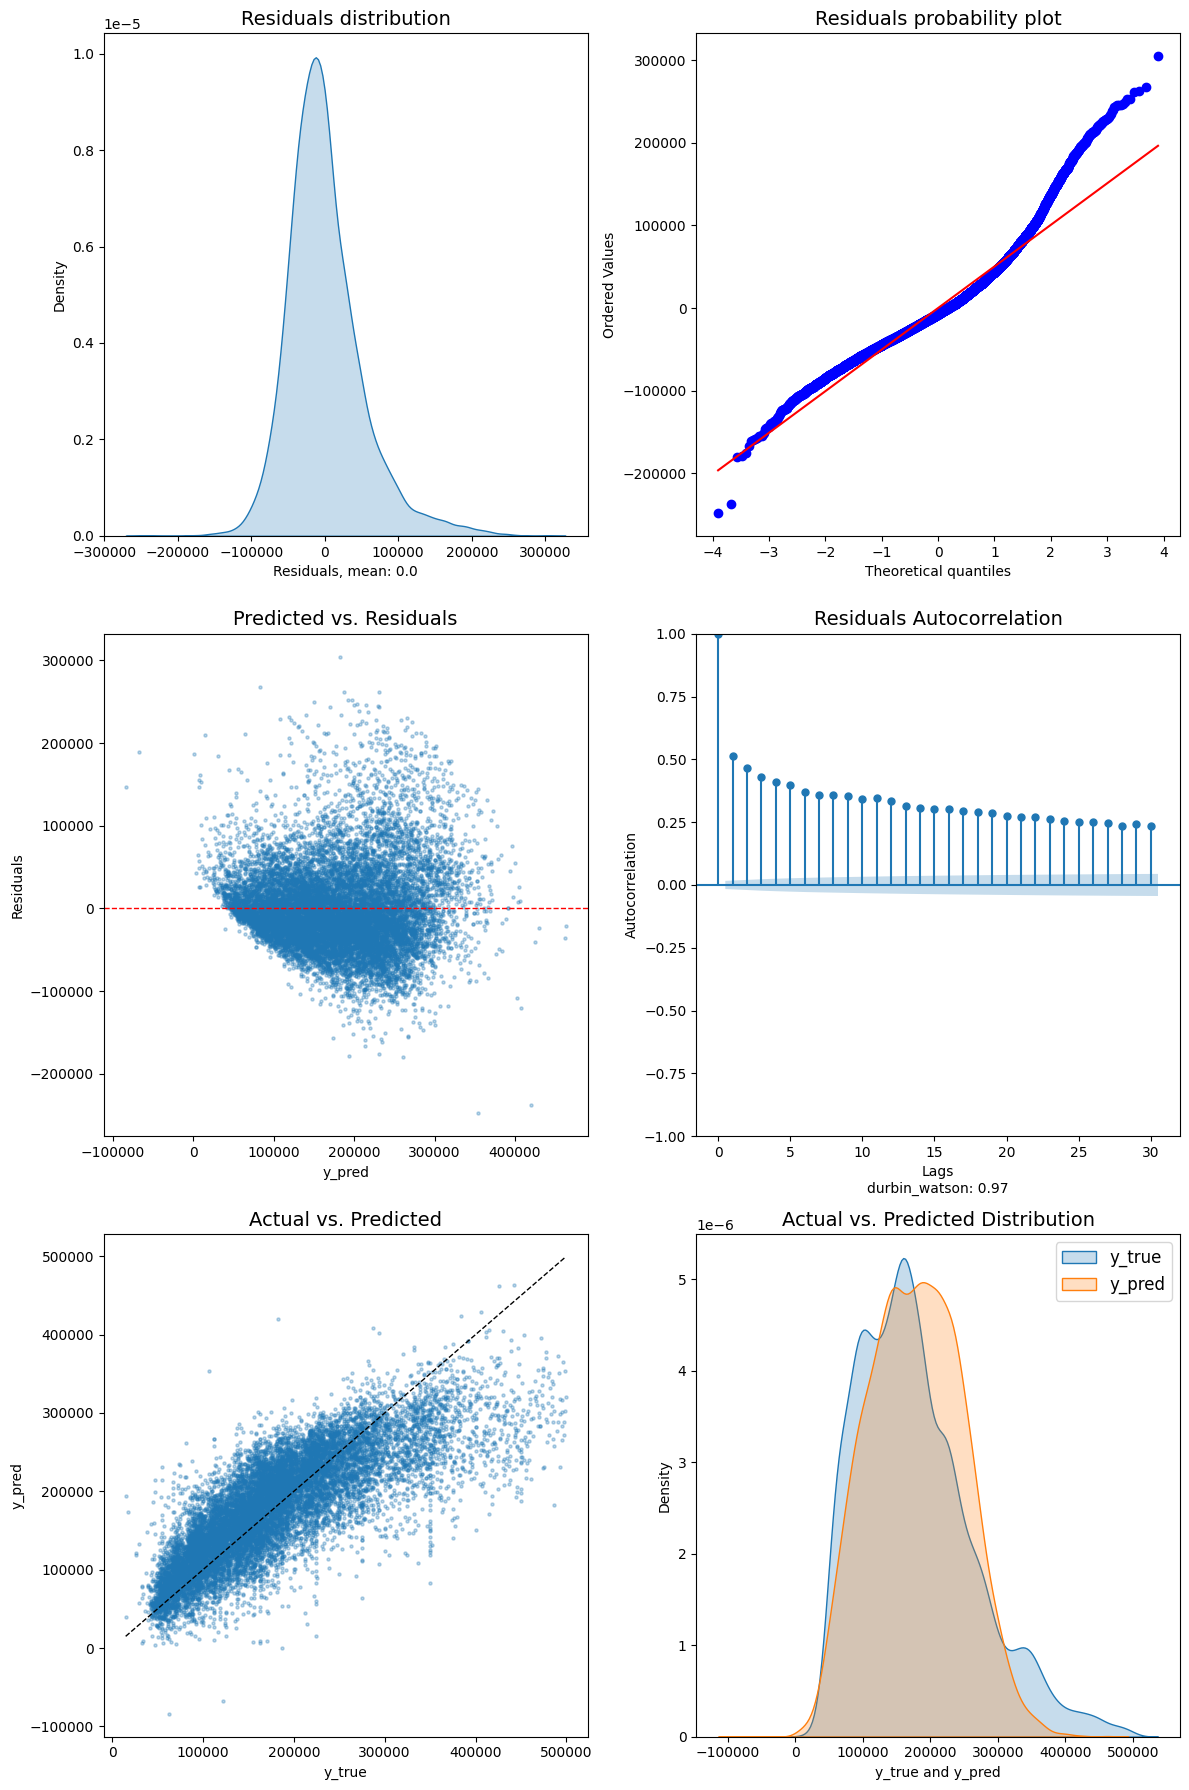

In [219]:
diagnostics(y, y_pred)

## Мультиколлинеарность признаков (VIF)

**Мультиколлинеарность** — это высокая корреляция между признаками.
Она затрудняет интерпретацию коэффициентов модели.

**VIF (Variance Inflation Factor)** показывает, насколько дисперсия коэффициента
регрессии для данного признака увеличена из-за мультиколлинеарности:
- VIF < 5 — допустимо
- 5 ≤ VIF < 10 — умеренная мультиколлинеарность
- VIF ≥ 10 — высокая мультиколлинеарность

Анализируем только числовые признаки (без OHE-столбцов `ocean_proximity`).

In [220]:
def vif(df, features):
    from sklearn.linear_model import LinearRegression
    vif_dict, tolerance_dict = {}, {}

    for feature in features:
        X_other = [f for f in features if f != feature]
        X_vif, y_vif = df[X_other], df[feature]
        r2 = LinearRegression().fit(X_vif, y_vif).score(X_vif, y_vif)

        tolerance_dict[feature] = 1 - r2
        vif_dict[feature] = 1 / (tolerance_dict[feature])

    return pd.DataFrame({'VIF': vif_dict, 'Tolerance': tolerance_dict})

In [221]:
# Числовые признаки (без OHE-столбцов и без целевой переменной)
num_features = ['longitude', 'latitude', 'housing_median_age',
                'total_rooms', 'total_bedrooms', 'population',
                'households', 'median_income']

vif(df=X, features=num_features)

,VIF,Tolerance
longitude,8.298193,0.120508
latitude,9.215280,0.108515
housing_median_age,1.218220,0.820870
total_rooms,7.615641,0.131309
total_bedrooms,14.418379,0.069356
population,3.571052,0.280030
households,16.444258,0.060812
median_income,2.118946,0.471933


**Ожидаемый результат:** `total_rooms`, `total_bedrooms`, `households` и `population`
будут иметь высокий VIF, так как все они измеряют «размер квартала».

Будем удалять параметры с наибольшими значениями VIF по-одному, и проверять, как это повлияет на данные.

In [222]:
california.drop(columns=['households'], inplace=True)
print('Признаки после удаления:', california.drop(columns='median_house_value').columns.tolist())

Признаки после удаления: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_NEAR_BAY', 'ocean_proximity_NEAR_OCEAN']


Проверим VIF снова:

In [223]:
# Числовые признаки (без OHE-столбцов и без целевой переменной)
num_features = ['longitude', 'latitude', 'housing_median_age',
                'total_rooms', 'total_bedrooms', 'population',
                'median_income']

vif(df=X, features=num_features)

,VIF,Tolerance
longitude,7.889900,0.126744
latitude,8.771121,0.114011
housing_median_age,1.215605,0.822635
total_rooms,7.241867,0.138086
total_bedrooms,7.329601,0.136433
population,2.816682,0.355028
median_income,2.112700,0.473328


Как видим, значения VIF улучшились, не осталось ни одного признакам с VIF ≥ 10

## Улучшение модели: PowerTransformer

**PowerTransformer** применяет степенное преобразование (Yeo-Johnson или Box-Cox)
к каждому признаку, стремясь сделать его распределение более нормальным.
Линейная регрессия лучше работает, когда признаки распределены нормально.

In [224]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
california = pd.DataFrame(pt.fit_transform(california),
                          columns=california.columns)
california.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,median_income,ocean_proximity_INLAND,ocean_proximity_NEAR_BAY,ocean_proximity_NEAR_OCEAN,median_house_value
0,-1.445388,1.182792,2.007477,0.540825,0.378010,-0.064905,0.243791,-0.75516,4.382864,-0.234953,1.321134
1,-1.448612,1.185502,2.007477,0.220957,0.107871,-0.448731,-0.101385,-0.75516,4.382864,-0.234953,1.180297
2,-1.448612,1.185502,2.007477,0.500504,0.307308,-0.057090,-0.206011,-0.75516,4.382864,-0.234953,0.566494
3,-1.451832,1.185502,2.007477,-0.030736,-0.384301,-0.716388,-0.463009,-0.75516,4.382864,-0.234953,-0.128477
4,-1.448612,1.182792,1.831966,0.258343,0.214694,-0.276098,-1.205775,-0.75516,4.382864,-0.234953,-0.049013


### Корреляция признаков с целевой переменной после трансформации

In [225]:
california.drop(columns=[c for c in california.columns if 'ocean_proximity' in c]).corr()['median_house_value'].to_frame().style.background_gradient()

,median_house_value
longitude,0.117893
latitude,-0.317540
housing_median_age,0.040705
total_rooms,0.192308
total_bedrooms,0.088529
population,0.022887
median_income,0.648159
median_house_value,1.000000


Среди числовых признаков наибольшую связь с целевой переменной сохраняет median_income  — это главный предиктор стоимости жилья. latitude имеет умеренную отрицательную корреляцию: чем севернее квартал, тем ниже цена. Остальные числовые признаки демонстрируют слабую связь, а population и housing_median_age практически не коррелируют с целью линейно.

Посмотрим на корреляции OHE-столбцов:

In [226]:
ohe_cols = [c for c in california.columns if 'ocean_proximity' in c]
california[ohe_cols + ['median_house_value']].corr()['median_house_value'].to_frame().style.background_gradient()

,median_house_value
ocean_proximity_INLAND,-0.603303
ocean_proximity_NEAR_BAY,0.039619
ocean_proximity_NEAR_OCEAN,0.070813
median_house_value,1.000000


  Среди OHE-столбцов выделяется ocean_proximity_INLAND с сильной отрицательной корреляцией: расположение в глубине материка существенно снижает стоимость жилья. ocean_proximity_NEAR_OCEAN и ocean_proximity_NEAR_BAY имеют слабую положительную связь.

### Удаление низкокоррелированных признаков

In [227]:
# Посмотрим полную таблицу корреляций с целевой переменной
corr_target = california.corr()['median_house_value'].drop('median_house_value').abs().sort_values()
print(corr_target.to_string())

population                    0.022887
ocean_proximity_NEAR_BAY      0.039619
housing_median_age            0.040705
ocean_proximity_NEAR_OCEAN    0.070813
total_bedrooms                0.088529
longitude                     0.117893
total_rooms                   0.192308
latitude                      0.317540
ocean_proximity_INLAND        0.603303
median_income                 0.648159


In [228]:
# Удалим признаки с |corr| < 0.05
drop_cols = corr_target[corr_target < 0.05].index.tolist()

print('Удаляем:', drop_cols)
california.drop(columns=drop_cols, inplace=True)
california.shape

Удаляем: ['population', 'ocean_proximity_NEAR_BAY', 'housing_median_age']


(14470, 8)

## Финальная модель

In [229]:
X = california.drop(columns='median_house_value')
y = california['median_house_value']

model = LinearRegression()
y_pred = model.fit(X, y).predict(X)

In [230]:
mape(y, y_pred)

np.float64(4.639769350384747)

In [231]:
r_squared(X, y, y_pred)

(np.float64(0.6481498652811629), np.float64(0.6479795602788789))

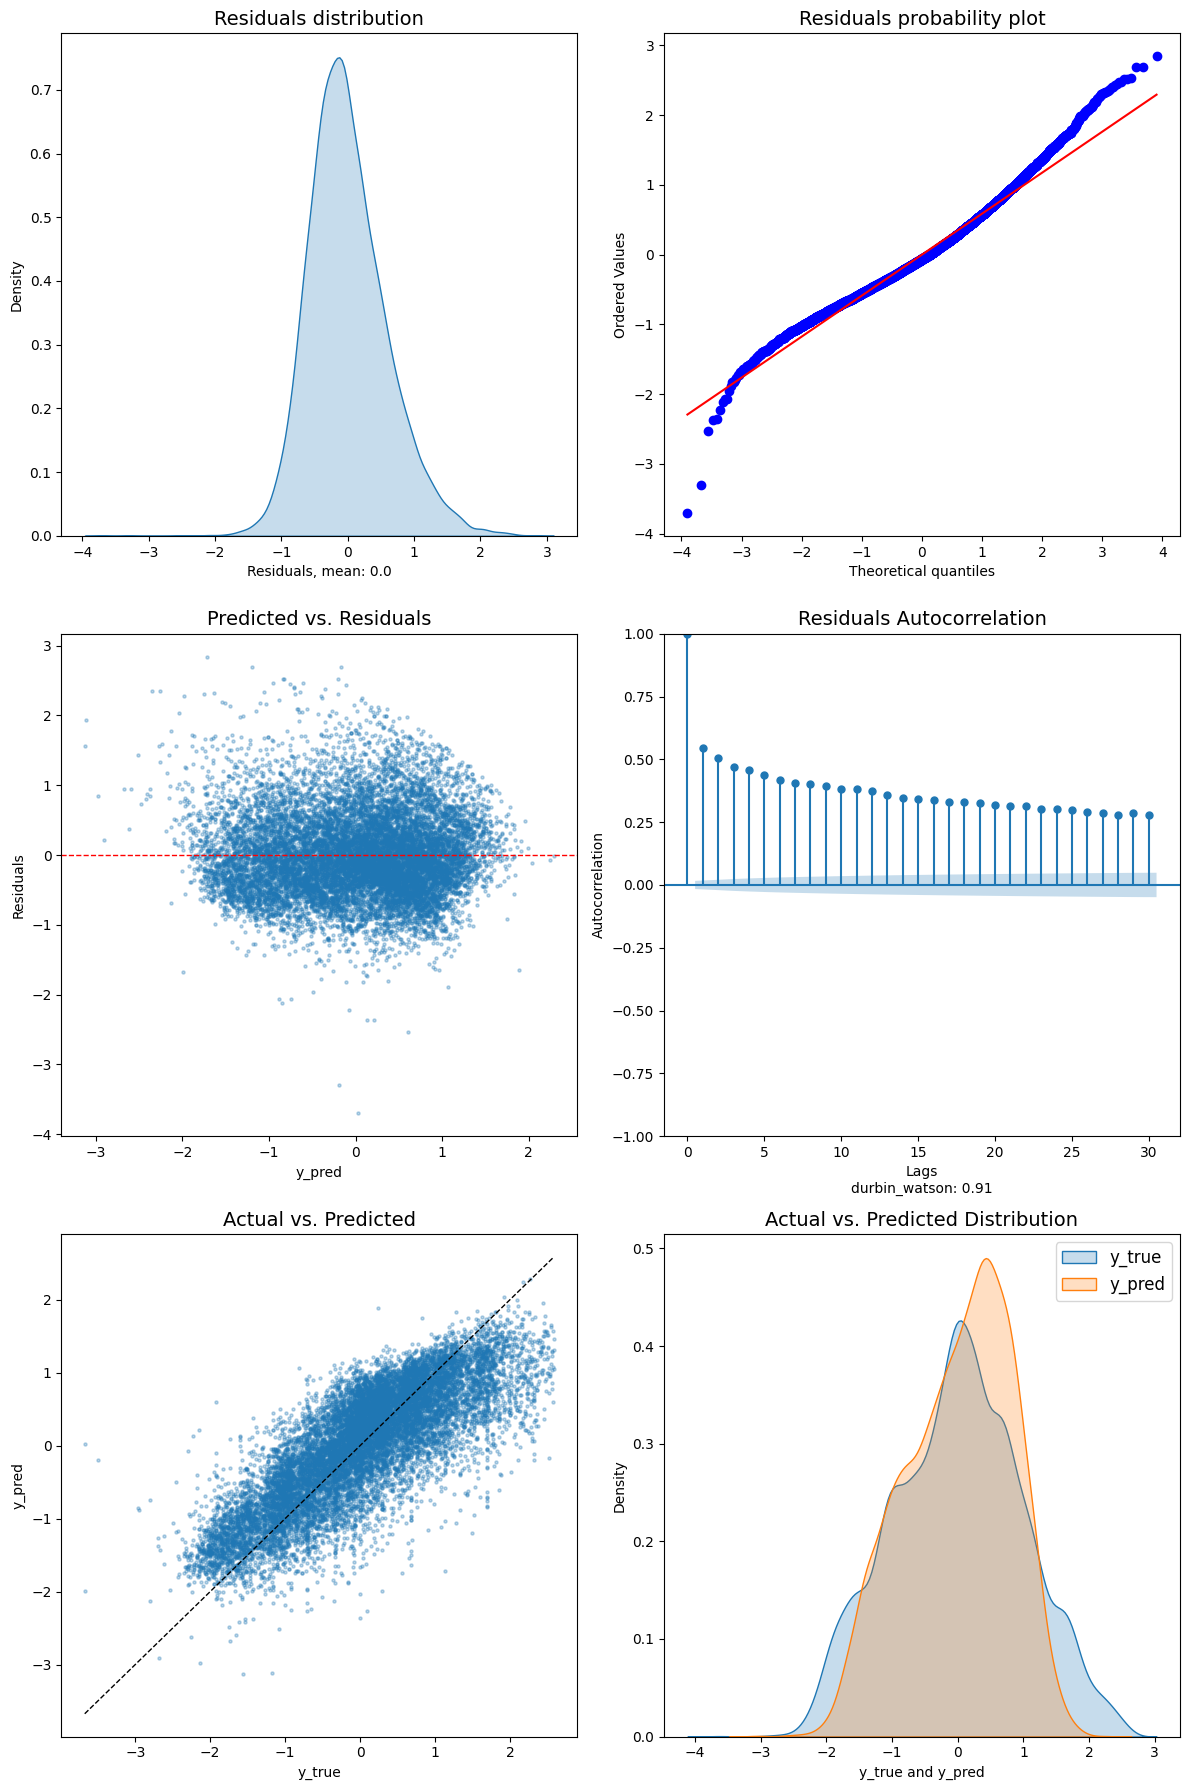

In [232]:
diagnostics(y, y_pred)

### Коэффициенты модели

Intercept: -5.631138034489699e-16


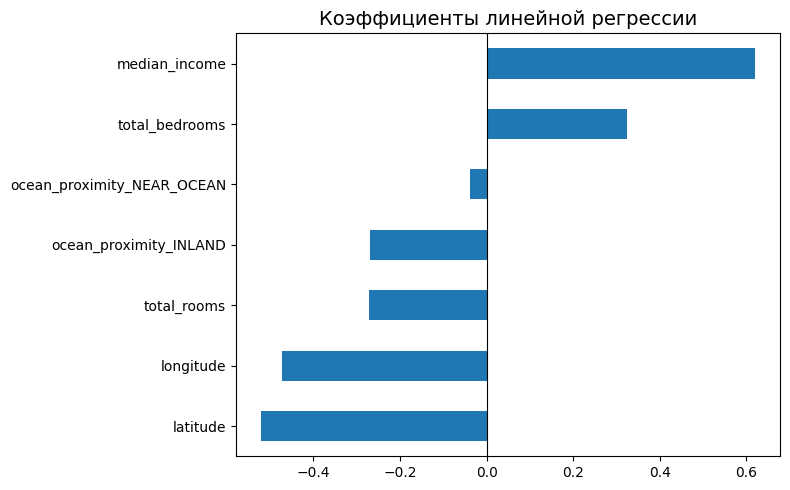

In [233]:
print('Intercept:', model.intercept_)
pd.Series(model.coef_, index=X.columns).sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Коэффициенты линейной регрессии', fontsize=14)
plt.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

## Функции потерь

### L1 и L2

При обучении модели мы минимизируем функцию потерь.
Рассмотрим два основных варианта:

In [234]:
def L1(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / y_true.size

def L2(y_true, y_pred):
    return np.sum((y_true - y_pred) ** 2) / y_true.size

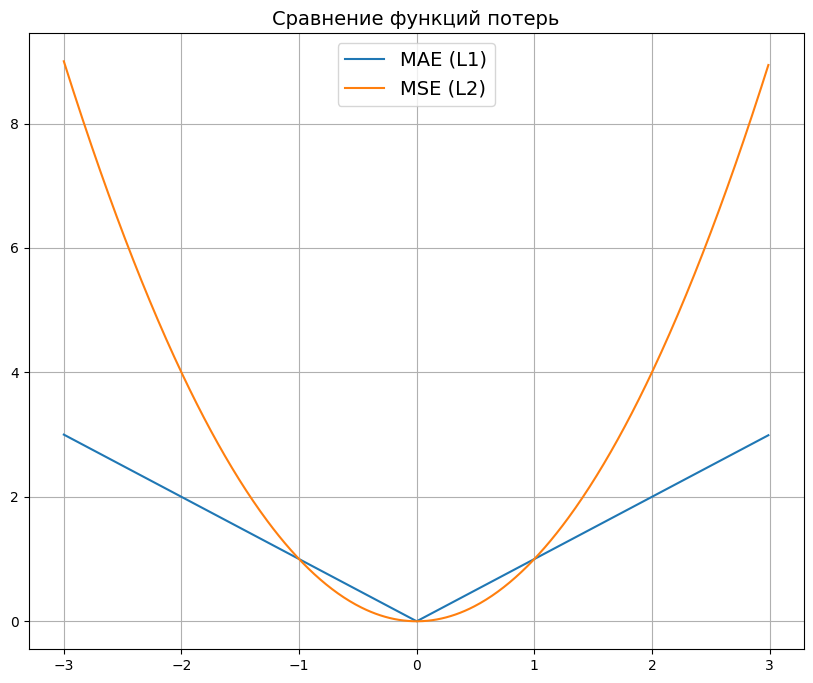

In [235]:
def mse_plot(x):
    return x ** 2

def mae_plot(x):
    return np.abs(x)

plt.figure(figsize=(10, 8))
x_vals = np.arange(-3, 3, 0.01)
plt.plot(x_vals, mae_plot(x_vals), label='MAE (L1)')
plt.plot(x_vals, mse_plot(x_vals), label='MSE (L2)')
plt.legend(loc='upper center', prop={'size': 14})
plt.title('Сравнение функций потерь', fontsize=14)
plt.grid()
plt.show()

### Функция потерь Хьюбера

**Huber loss** — компромисс между L1 и L2:
- При малых ошибках (|e| ≤ δ) ведёт себя как квадратичная (чувствительна к точным значениям)
- При больших ошибках (|e| > δ) — как линейная (устойчива к выбросам)

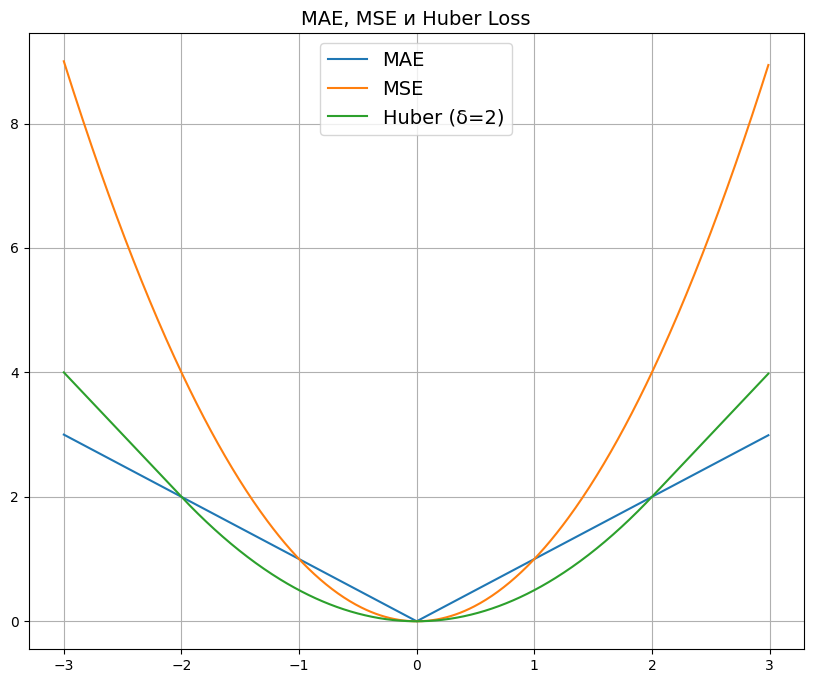

In [236]:
def huber(x, delta=1.):
    huber_mse = 0.5 * np.square(x)
    huber_mae = delta * (np.abs(x) - 0.5 * delta)
    return np.where(np.abs(x) <= delta, huber_mse, huber_mae)

plt.figure(figsize=(10, 8))
x_vals = np.arange(-3, 3, 0.01)
plt.plot(x_vals, mae_plot(x_vals), label='MAE')
plt.plot(x_vals, mse_plot(x_vals), label='MSE')
plt.plot(x_vals, huber(x_vals, delta=2), label='Huber (δ=2)')
plt.legend(loc='upper center', prop={'size': 14})
plt.title('MAE, MSE и Huber Loss', fontsize=14)
plt.grid()
plt.show()

На графике показаны три способа измерять ошибку модели:                                                      
                                                                                                               
  - MSE (оранжевая) — возводит ошибку в квадрат, поэтому растёт очень быстро. Если модель сильно ошиблась,     
  штраф будет огромным. Из-за этого один большой выброс может сильно испортить всю модель
  - MAE (синяя) — просто берёт модуль ошибки, поэтому растёт равномерно и не так сильно реагирует на выбросы.  
  Но у неё есть технический недостаток: в точке 0 производная не определена, что мешает градиентному спуску  
  - Huber (зелёная, δ=2) — пытается взять лучшее от обоих вариантов. При небольших ошибках (в районе нуля)
  ведёт себя как MSE, а при больших — переходит на линейный рост, как MAE. На графике видно, что при значениях
  ±2 зелёная линия перестаёт следовать за оранжевой и дальше растёт гораздо медленнее

  Вывод: Если в данных есть выбросы — Huber loss будет лучшим выбором, так как не позволяет им слишком сильно
  влиять на обучение модели.



## МНК: реализация с нуля

### Метод наименьших квадратов (МНК / OLS)

Аналитическое решение задачи линейной регрессии реализуем в виде класса, похожего на sklearn-интерфейс.

In [237]:
class Ols():
    def __init__(self):
        self.thetas = None

    def add_ones(self, x):
        return x.insert(0, 'x0', np.ones(x.shape[0]))

    def fit(self, x, y):
        x = x.copy()
        self.add_ones(x)
        xT = x.T

        inversed = np.linalg.inv(np.dot(xT, x))
        self.thetas = inversed.dot(xT).dot(y)

    def predict(self, x):
        x = x.copy()
        self.add_ones(x)
        return np.dot(x, self.thetas)

In [238]:
ols_model = Ols()
ols_model.fit(X, y)

In [239]:
print('Intercept:', ols_model.thetas[0])
print('Coef:', ols_model.thetas[1:])

Intercept: -2.373318555570769e-16
Coef: [-0.4722807  -0.52191605 -0.27211048  0.32491453  0.62080405 -0.26841227
 -0.03742004]


In [240]:
y_pred_ols = ols_model.predict(X)
y_pred_ols[:5]

array([ 0.40380013,  0.18888908,  0.11266911, -0.12551325, -0.47077093])

In [241]:
mape(y, y_pred_ols)

np.float64(4.639769350384754)

In [242]:
r_squared(X, y, y_pred_ols)

(np.float64(0.6481498652811629), np.float64(0.6479795602788789))

В этом блоке мы реализовали линейную регрессию с нуля, используя
аналитическую формулу МНК.

Главный недостаток МНК — вычисление обратной матрицы, которое становится очень дорогим при большом числе признаков. Именно поэтому на практике при больших данных чаще используют градиентный спуск, который мы рассмотрим в следующем блоке.

## Градиентный спуск: реализация с нуля

### Алгоритм

Вместо аналитического решения можно итеративно минимизировать функцию потерь,
двигаясь в направлении, обратном градиенту

> **Примечание:** датасет California содержит ~18 000 строк, поэтому обучение
> на 10 000 итерациях займёт заметное время.

In [243]:
def add_ones_arr(x):
    return x.insert(0, 'x0', np.ones(x.shape[0]))

def h(x, thetas):
    return np.dot(x, thetas)

def objective(x, y, thetas, n):
    return np.sum((y - h(x, thetas)) ** 2) / (2 * n)

def gradient(x, y, thetas, n):
    return np.dot(x.T, (h(x, thetas) - y)) * (1/n)

def fit_gd(x, y, n_iter=10000, learning_rate=0.05):
    x = x.copy()
    add_ones_arr(x)

    thetas, n = np.zeros(x.shape[1]), x.shape[0]
    loss_history = []

    for i in range(n_iter):
        loss_history.append(objective(x, y, thetas, n))
        grad = gradient(x, y, thetas, n)
        thetas -= learning_rate * grad

    return thetas, loss_history

In [244]:
thetas, loss_history = fit_gd(X, y, n_iter=10000, learning_rate=0.05)

In [245]:
print('Intercept:', thetas[0])
print('Coef:', thetas[1:])
print('Final loss:', loss_history[-1])

Intercept: -5.699683219444567e-16
Coef: [-0.47227732 -0.52191215 -0.27211067  0.32491469  0.62080417 -0.26841342
 -0.03741975]
Final loss: 0.17592506735974572


Вывод:                                                                                                    
В этом блоке мы реализовали градиентный спуск с нуля — итеративный метод поиска оптимальных коэффициентов    
модели. В отличие от МНК, который находит ответ за один шаг, градиентный спуск двигается к минимуму функции
потерь маленькими шагами, каждый раз обновляя веса в направлении, противоположном градиенту.

Два ключевых параметра алгоритма:
- learning rate — размер шага. Слишком большой — алгоритм будет «перепрыгивать» минимум, слишком маленький — сходиться очень долго
- количество итераций — сколько шагов делает алгоритм. График истории потерь показывает, что основное снижение ошибки происходит в первых итерациях, после чего кривая выходит на плато

### Класс GD

In [246]:
class Gd():
    def __init__(self):
        self.thetas = None
        self.loss_history = []

    def add_ones(self, x):
        return x.insert(0, 'x0', np.ones(x.shape[0]))

    def objective(self, x, y, thetas, n):
        return np.sum((y - self.h(x, thetas)) ** 2) / (2 * n)

    def h(self, x, thetas):
        return np.dot(x, thetas)

    def gradient(self, x, y, thetas, n):
        return np.dot(x.T, (self.h(x, thetas) - y)) * (1/n)

    def fit(self, x, y, n_iter=10000, learning_rate=0.05):
        x, y = x.copy(), y.copy()
        self.add_ones(x)

        thetas, n = np.zeros(x.shape[1]), x.shape[0]
        loss_history = []

        for i in range(n_iter):
            loss_history.append(self.objective(x, y, thetas, n))
            grad = self.gradient(x, y, thetas, n)
            thetas -= learning_rate * grad

        self.thetas = thetas
        self.loss_history = loss_history

    def predict(self, x):
        x = x.copy()
        self.add_ones(x)
        return np.dot(x, self.thetas)

In [247]:
gd_model = Gd()
gd_model.fit(X, y, n_iter=10000, learning_rate=0.05)

print('Intercept:', gd_model.thetas[0])
print('Final loss:', gd_model.loss_history[-1])

y_pred_gd = gd_model.predict(X)

Intercept: -5.699683219444567e-16
Final loss: 0.17592506735974572


In [248]:
results = pd.DataFrame({
  'Метод': ['sklearn', 'МНК (OLS)', 'Градиентный спуск'],
  'MAPE': [
      mape(y, y_pred),
      mape(y, y_pred_ols),
      mape(y, y_pred_gd)
  ],
  'R²': [
      r_squared(X, y, y_pred)[0],
      r_squared(X, y, y_pred_ols)[0],
      r_squared(X, y, y_pred_gd)[0]
  ]
})

results

,Метод,MAPE,R²
0,sklearn,4.639769,0.64815
1,МНК (OLS),4.639769,0.64815
2,Градиентный спуск,4.639769,0.64815


Все три метода дают одинаковые значения MAPE и R², что подтверждает корректность реализации МНК и градиентного спуска с нуля.

In [249]:
print('MAPE:', mape(y, y_pred_gd))
print('R², R²_adj:', r_squared(X, y, y_pred_gd))

MAPE: 4.639769485282314
R², R²_adj: (np.float64(0.64814986528051), np.float64(0.6479795602782257))


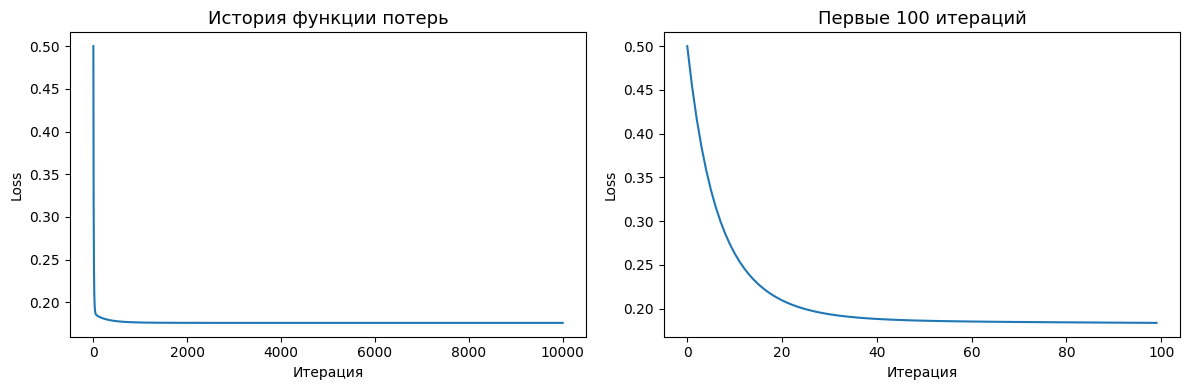

In [250]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(gd_model.loss_history)
plt.title('История функции потерь', fontsize=13)
plt.xlabel('Итерация')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(gd_model.loss_history[:100])
plt.title('Первые 100 итераций', fontsize=13)
plt.xlabel('Итерация')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

Вывод:                                                                                                         
График истории функции потерь показывает, как алгоритм обучается. На левом графике видно, что за 10 000      
итераций функция потерь снизилась с ~0.50 до ~0.18 и вышла на плато — это значит, что модель сошлась и       
дальнейшее увеличение числа итераций уже не даст заметного улучшения.                                        
                                                                                                              
Правый график (первые 100 итераций) наглядно показывает, что основное снижение ошибки происходит в самом
начале обучения — уже к ~50-й итерации функция потерь падает более чем вдвое. После этого улучшения
становятся всё меньше с каждым шагом.

## Визуализация градиентного спуска

Рассмотрим пример: минимизируем функцию $f(w_1, w_2) = \frac{w_1^2}{a} + \frac{w_2^2}{b}$

Это позволяет наглядно увидеть, как масштаб признаков влияет на траекторию оптимизации.

In [251]:
def paraboloid_contours(min_val, max_val, a=1, b=1, w1_list=None, w2_list=None):
    fig, ax = plt.subplots(figsize=(10, 10))

    w1_plot = np.arange(min_val, max_val, 0.02)
    w2_plot = np.arange(min_val, max_val, 0.02)
    w1_plot, w2_plot = np.meshgrid(w1_plot, w2_plot)

    f = (w1_plot ** 2) / a + (w2_plot ** 2) / b
    ax.contourf(w1_plot, w2_plot, f, cmap='Blues')

    if w1_list is not None and w2_list is not None:
        ax.plot(w1_list, w2_list, c='red')

    ax.set_xlabel('w1', fontsize=15)
    ax.set_ylabel('w2', fontsize=15)
    plt.grid(linestyle='--')
    plt.show()


def objective_2d(w1, w2, a, b):
    return (w1 ** 2) / a + (w2 ** 2) / b

def partial_1(w1, a):
    return (2.0 * w1) / a

def partial_2(w2, b):
    return (2.0 * w2) / b


def paraboloid_gd(w1, w2, a, b, n_iter=100, learning_rate=0.025):
    w1_list, w2_list, l_list = [], [], []

    for i in range(n_iter):
        w1_list.append(w1)
        w2_list.append(w2)
        l_list.append(objective_2d(w1, w2, a, b))

        par_1 = partial_1(w1, a)
        par_2 = partial_2(w2, b)

        w1 = w1 - learning_rate * par_1
        w2 = w2 - learning_rate * par_2

    return w1_list, w2_list, l_list

#### Случай с разным масштабом признаков (a=1, b=5) — «вытянутая» чаша

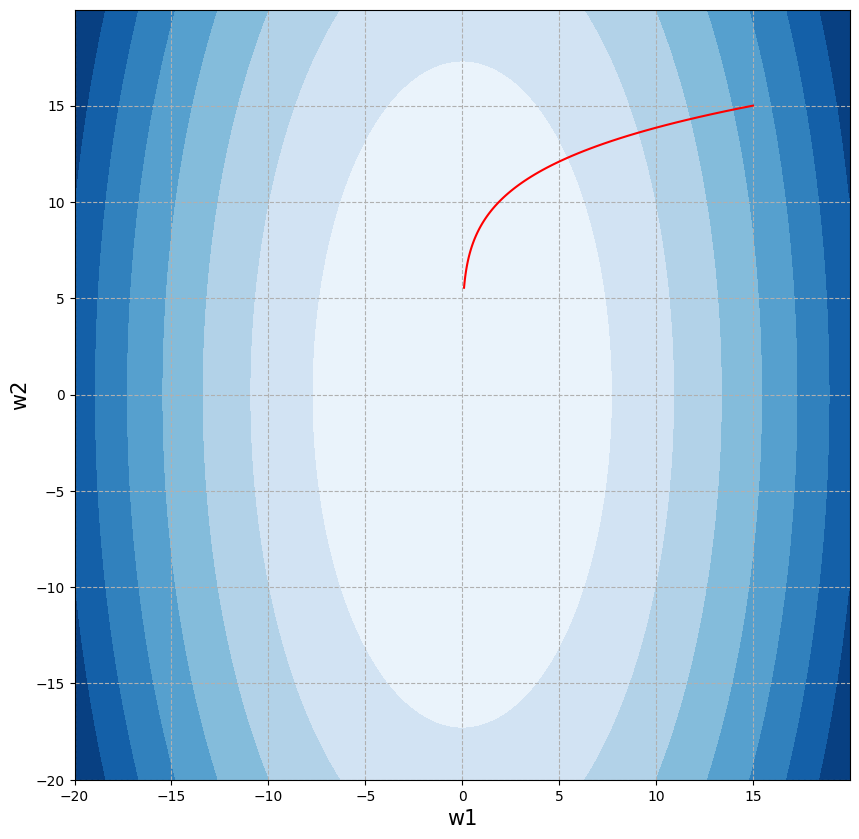

In [252]:
w1_list, w2_list, l_list = paraboloid_gd(15, 15, 1, 5)
paraboloid_contours(-20, 20, 1, 5, w1_list, w2_list)

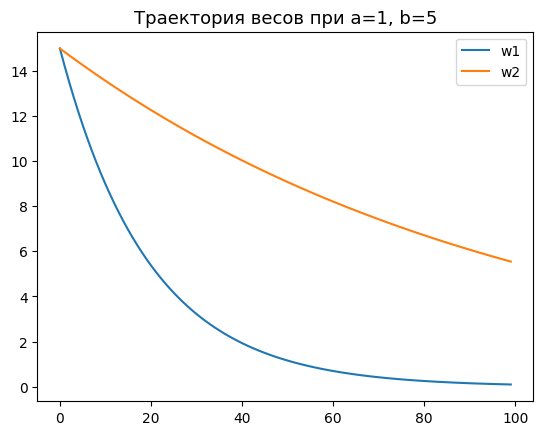

In [253]:
plt.plot(w1_list, label='w1')
plt.plot(w2_list, label='w2')
plt.legend()
plt.title('Траектория весов при a=1, b=5', fontsize=13)
plt.show()

**Наблюдение:** При разном масштабе признаков (a≠b) градиентный спуск
движется зигзагообразно и медленнее сходится. Именно поэтому стандартизация данных
критически важна для градиентного спуска.

#### Случай с одинаковым масштабом признаков (a=1, b=1) — симметричная чаша

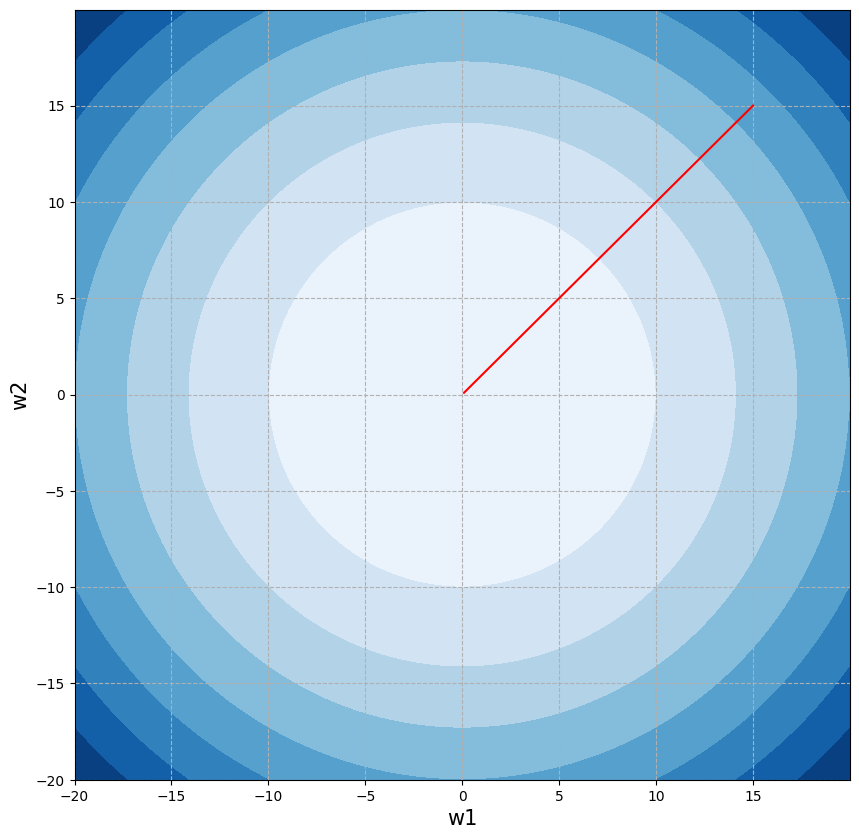

In [254]:
w1_list, w2_list, l_list = paraboloid_gd(15, 15, 1, 1)
paraboloid_contours(-20, 20, 1, 1, w1_list, w2_list)

Вывод:                                                                                                         
При одинаковом масштабе признаков (a=1, b=1) контуры функции потерь становятся круговыми, и градиентный спуск
  ведёт себя совсем иначе: траектория (красная линия) идёт прямо к минимуму без каких-либо зигзагов — из точки
  (15, 15) в точку (0, 0) по кратчайшему пути.                                                                
                                                                                                            
Это наглядно показывает, почему стандартизация данных так важна перед обучением модели: когда все признаки
находятся в одном масштабе, градиентный спуск сходится быстро и эффективно. В реальных данных признаки всегда
  имеют разные единицы и диапазоны значений — именно поэтому мы стандартизировали данные в самом начале
работы.

## Полиномиальная регрессия

Линейная регрессия предполагает линейную зависимость между признаками и целью.
Если зависимость нелинейная (например, квадратичная), можно добавить полиномиальные признаки.

Рассмотрим на примере зависимости `median_house_value` от `median_income`.

Linear — RMSE: 0.7615, R²: 0.4201


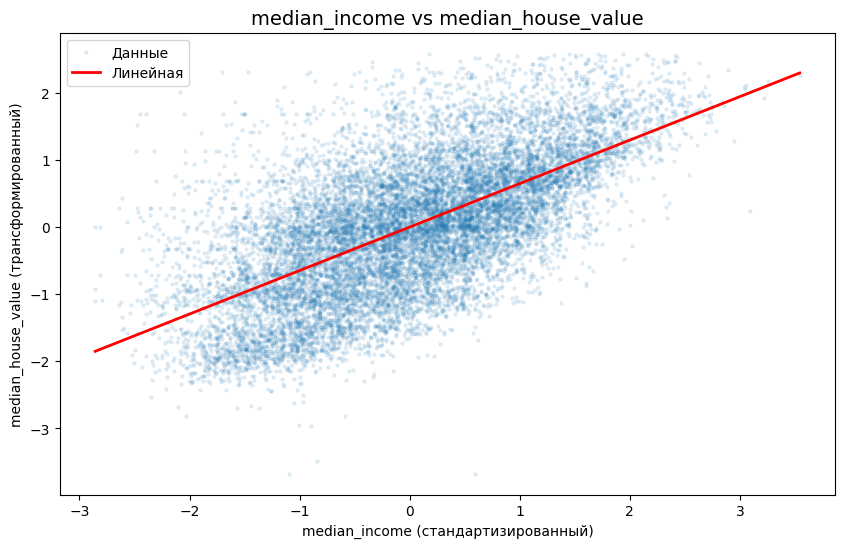

In [255]:
# Возьмём последнюю версию данных X, y (после всех трансформаций)
X_inc = X[['median_income']].values
y_inc = y.values

# Простая линейная регрессия
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_inc, y_inc)
y_lin_pred = lin_model.predict(X_inc)

print(f'Linear — RMSE: {root_mean_squared_error(y_inc, y_lin_pred):.4f}, R²: {r2_score(y_inc, y_lin_pred):.4f}')

# Сортируем для красивого графика
sort_idx = X_inc[:, 0].argsort()

plt.figure(figsize=(10, 6))
plt.scatter(X_inc, y_inc, alpha=0.1, s=5, label='Данные')
plt.plot(X_inc[sort_idx], y_lin_pred[sort_idx], color='red', lw=2, label='Линейная')
plt.title('median_income vs median_house_value', fontsize=14)
plt.xlabel('median_income (стандартизированный)')
plt.ylabel('median_house_value (трансформированный)')
plt.legend()
plt.show()

Polynomial (degree=2) — RMSE: 0.7596, R²: 0.4230


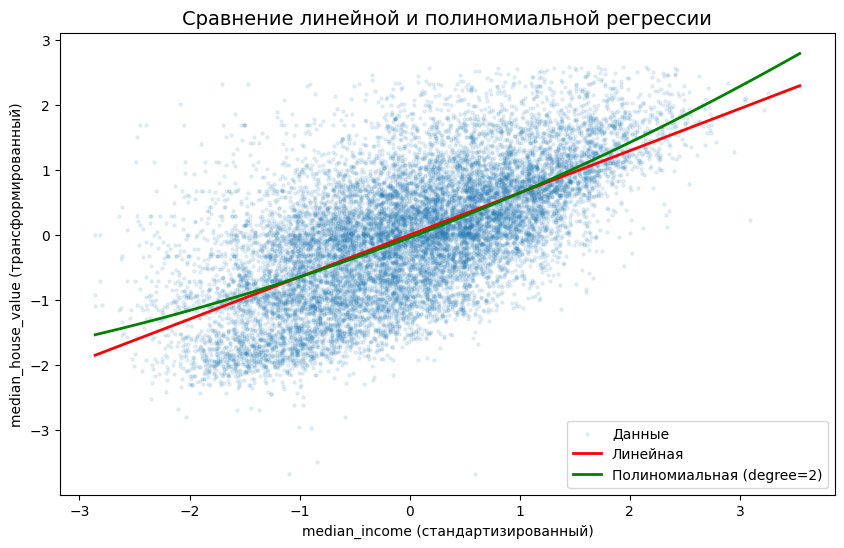

In [256]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = polynomial_features.fit_transform(X_inc)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_inc)
y_poly_pred = poly_model.predict(X_poly)

print(f'Polynomial (degree=2) — RMSE: {root_mean_squared_error(y_inc, y_poly_pred):.4f}, R²: {r2_score(y_inc, y_poly_pred):.4f}')

# Сортируем для красивого графика
X_poly_sorted = X_poly[sort_idx]
y_poly_sorted = y_poly_pred[sort_idx]

plt.figure(figsize=(10, 6))
plt.scatter(X_inc, y_inc, alpha=0.1, s=5, label='Данные')
plt.plot(X_inc[sort_idx], y_lin_pred[sort_idx], color='red', lw=2, label='Линейная')
plt.plot(X_inc[sort_idx], y_poly_sorted, color='green', lw=2, label='Полиномиальная (degree=2)')
plt.title('Сравнение линейной и полиномиальной регрессии', fontsize=14)
plt.xlabel('median_income (стандартизированный)')
plt.ylabel('median_house_value (трансформированный)')
plt.legend()
plt.show()

In [257]:
comparison = pd.DataFrame({
    'Модель': ['Линейная', 'Полиномиальная (degree=2)'],
    'RMSE': [
        root_mean_squared_error(y_inc, y_lin_pred),
        root_mean_squared_error(y_inc, y_poly_pred)
    ],
    'R²': [
        r2_score(y_inc, y_lin_pred),
        r2_score(y_inc, y_poly_pred)
    ]
})

comparison

,Модель,RMSE,R²
0,Линейная,0.761505,0.420110
1,Полиномиальная (degree=2),0.759618,0.422981


**Итог:**
                            
Полиномиальная регрессия 2-й степени даёт лишь незначительное улучшение по сравнению с линейной. Это говорит о том, что зависимость между median_income и median_house_value в данных после PowerTransformer уже достаточно близка к линейной, и добавление полиномиальных признаков практически не помогает. Для заметного улучшения модели нужно добавлять остальные признаки, а не усложнять степень полинома.